In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
import sys
sys.path.append(str(Path("../src").resolve()))
from radar_lwc.preprocessing.clean import drop_duplicate_times

In [2]:
ds_ka = xr.open_mfdataset(r"C:\Projects\Masterarbeit\dual_freq_radar_lwc\data\raw\cmtrace\20230928\*ZEN.LV1.nc")        #r in front of path makes python understand them as literal. Instead \ often a command
ds_w = xr.open_mfdataset(r"C:\Projects\Masterarbeit\dual_freq_radar_lwc\data\raw\cmtrace\20230928_KaBand\*ZEN.LV1.nc")

In [4]:
import pandas as pd
epoch = pd.Timestamp("2001-01-01 00:00:00")
ds_w = ds_w.assign_coords(Time=epoch + pd.to_timedelta(ds_w["Time"].values, unit="s"))  

C:\Users\geron\AppData\Local\Temp\ipykernel_19684\642549115.py:3: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_w = ds_w.assign_coords(Time=epoch + pd.to_timedelta(ds_w["Time"].values, unit="s"))


In [5]:
import pandas as pd
epoch = pd.Timestamp("2001-01-01 00:00:00")
ds_ka = ds_ka.assign_coords(Time=epoch + pd.to_timedelta(ds_ka["Time"].values, unit="s"))      # ds_ka["Time"] = ds_ka["Time"] + epoch doesnt work because timestamp needs delta t as addition and assign is better command apparently


C:\Users\geron\AppData\Local\Temp\ipykernel_19684\3279896365.py:3: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ds_ka = ds_ka.assign_coords(Time=epoch + pd.to_timedelta(ds_ka["Time"].values, unit="s"))      # ds_ka["Time"] = ds_ka["Time"] + epoch doesnt work because timestamp needs delta t as addition and assign is better command apparently


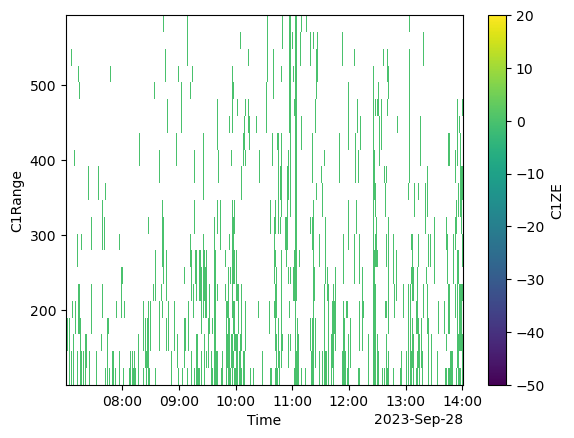

In [6]:
ds_ka["C1ZE"].plot(x="Time", y="C1Range", vmin=-50, vmax=20, cmap="viridis")    #cmap : Colormap irdis: default scientific colormap  /  turbo: alternative for meteorology

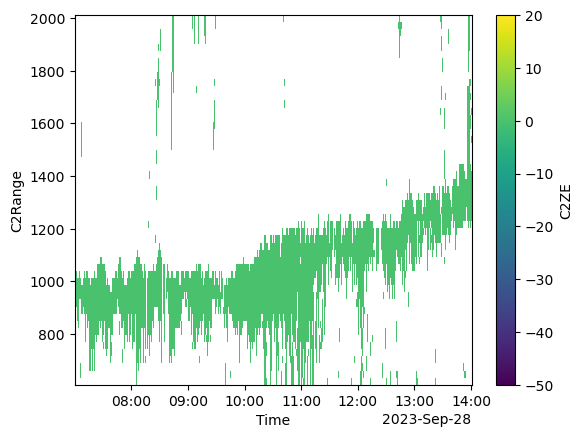

In [7]:
ds_ka["C2ZE"].plot(x="Time", y="C2Range", vmin=-50, vmax=20, cmap="viridis") 

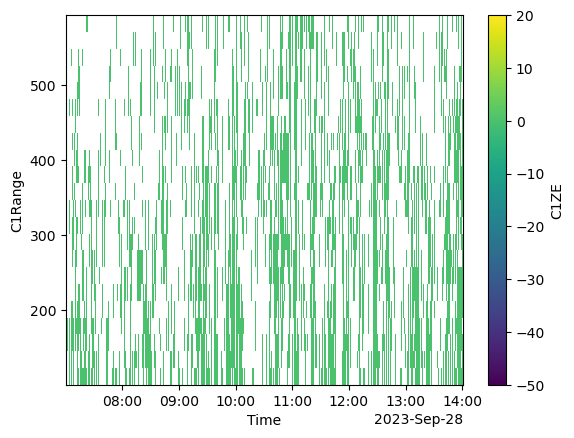

In [8]:
ds_w["C1ZE"].plot(x="Time", y="C1Range", vmin=-50, vmax=20, cmap="viridis") 

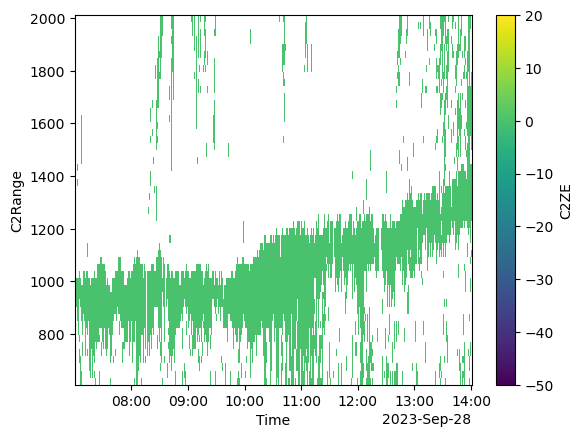

In [9]:
ds_w["C2ZE"].plot(x="Time", y="C2Range", vmin=-50, vmax=20, cmap="viridis") 

DWR CALCULATION

In [10]:
ds_w["C2ZE"] =10 * np.log10(ds_w["C2ZE"]) 

In [11]:
ds_ka["C2ZE"] =10 * np.log10(ds_ka["C2ZE"]) 

In [13]:
import numpy as np

print("W duplicates:", len(ds_w.Time) - len(np.unique(ds_w.Time)))
print("Ka duplicates:", len(ds_ka.Time) - len(np.unique(ds_ka.Time)))

W duplicates: 92
Ka duplicates: 92


In [14]:
ds_w = drop_duplicate_times(ds_w)
ds_ka = drop_duplicate_times(ds_ka)

In [15]:
dwr = ds_ka["C2ZE"] - ds_w["C2ZE"]

In [23]:
dwr_dh = np.gradient(dwr, dwr["C2Range"], axis=1)     # Values to differentiate, x-axis and "axis=1 means differentiate along the range axis (C2Range) of the dwr array and not time"
dwr_dh = dwr_dh * 1000
half_dwr_dh = 0.5 * dwr_dh

In [ ]:
half_dwr_dh = xr.DataArray(
    half_dwr_dh,            # numpy array with values
    dims=dwr.dims,          # dimension "Time" and "C2Range"
    coords=dwr.coords,      # coordinates    
    name="0.5_dDWR_dh"
)

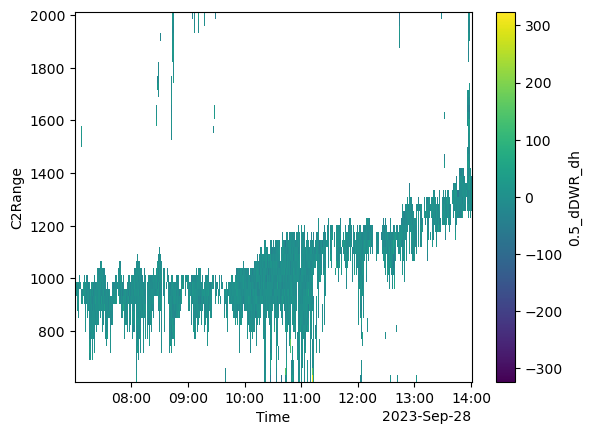

In [25]:
half_dwr_dh.plot(x="Time", y="C2Range", cmap="viridis") 

In [ ]:
alpha_w = 0.7    # dB/km
alpha_ka = 0.15  # dB/km

kappa_w = 4.2    # dB km^-1 (g m^-3)^-1
kappa_ka = 0.7   # dB km^-1 (g m^-3)^-1



delta_alpha = alpha_w - alpha_ka   # 0.55 dB/km
delta_kappa = kappa_w - kappa_ka   # 3.5 dB km^-1 (g m^-3)^-1

In [ ]:
def retrieve_lwc_zhu(dwr, alpha_w, alpha_ka, kappa_w, kappa_ka, window=7):

    h = dwr["C2Range"].values                # Array of heights
    n_time, n_range = dwr.shape              # For range in the loops

    lwc_sum = np.zeros((n_time, n_range))
    lwc_count = np.zeros((n_time, n_range))

    for t in range(n_time):

        for start in range(n_range - window + 1):    # +1 because in Python range is end-exclusive, so we need to add 1 to include the last index

            end = start + window

            h_win = h[start:end]                     # window heights array
            dwr_win = dwr.values[t, start:end]       # dwr values array at same heights

            # Quadratic fit
            mask = np.isfinite(h_win) & np.isfinite(dwr_win)      # checks if they are finite values and returns boolean array with True or False; Both need to be right
            if np.sum(mask) < 3:                                  # needs at least 3 points to fit a quadratic polynomial, otherwise skip this window
                continue
            a, b, c = np.polyfit(h_win[mask], dwr_win[mask], 2)      #Polynomial of second degree around heights and dwr values and returns a,b,c values.

            # dDWR/dh [dB/km]
            dDWR_dh = (2 * a * h_win + b) * 1000

            # Zhu Eq. (1)
            lwc_win = (0.5 * dDWR_dh - (alpha_w - alpha_ka)) / (kappa_w - kappa_ka)

            # Accumulate all window estimates
            lwc_sum[t, start:end] += lwc_win               #Counter and Adding up the LWC
            lwc_count[t, start:end] += 1

    lwc = lwc_sum / lwc_count

    return xr.DataArray(
        lwc,
        dims=dwr.dims,
        coords=dwr.coords,
        name="LWC",
    )

In [32]:
retrieve_lwc_zhu(dwr, alpha_w, alpha_ka, kappa_w, kappa_ka, window=7)

KeyboardInterrupt: 